# Optimization notebook
This notebook was developed as part of the Master’s thesis of June Rossen and is the notebook using multi-objective optimization to place wind turbines across Norway.

It uses:
- 6 objective functions
- 2 constraints

What is needed:
- A geodataframe of the study area, with the objective values and energy production for each cell

Workflow:
- Import necessary libraries, functions and data
- Define the problem parameters
- Define the problem and create an instance of it
- Create custom mutation and repair functions
- Create an initial population based on initial parents determined thanks to a MCDA approach
- Define the algorithm and launch the minimization
- Save the main results
- Do some post-run analysis
- Get an overview of results with a few plots
- Optionally save additional results of interest

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import dill

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib import rcParams

# Optimization package pymoo
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

from pymoo.core.population import Population
from pymoo.core.evaluator import Evaluator
from pymoo.core.mutation import Mutation
from pymoo.operators.crossover.pntx  import TwoPointCrossover
from pymoo.core.repair import Repair
from pymoo.termination import get_termination

from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from pymoo.core.callback import Callback
from pymoo.indicators.hv import HV
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA

from pymoo.visualization.pcp import PCP


In [ ]:
scenarios = ["100TWh", "NO1", "NO2", "NO3", "NO4", "NO5", "30TWh"]
s = 0

scenario = scenarios[s]
run = "NameMe"

input_data_filename = "Input_optimization/" + scenario + "_normalized_merged.gpkg"
F_mcda_filename = "Input_optimization/" + scenario + "_F_mcda.npy"
X_mcda_filename = "Input_optimization/" + scenario + "_X_mcda.csv"

result_filename = "Output_optimization/" + scenario + "_" + run + "_result.dill"
print("Result file name: ", result_filename)

cb_X_filename = "Output_optimization/" + scenario + "_" + run + "_cb_X.npy"
cb_F_filename = "Output_optimization/" + scenario + "_" + run + "_cb_F.npy"
cb_gen_filename = "Output_optimization/" + scenario + "_" + run + "_cb_gen.npy"

hv_filename = "Output_optimization/" + scenario + "_" + run + "_hv_values.npy"
diversity_metrics_filename = "Output_optimization/" + scenario + "_" + run + "_diversity_metrics.npy"

Result file name:  Output_optimization/100TWh_NameMe_result.dill


In [3]:
my_input_data = gpd.read_file(input_data_filename)

# Problem definition with parameter definition and custom mutation and repair functions

In [4]:
### Problem parameters
n_constraints = 2
n_objectives = 6

# we want 100 TWh for the first scenario, which in GWh is 100'000. Keep a 10 % upper bound to avoid overshooting production excessively. Adjust the scenario to adjust the target production.
region_shares = [1, 0.257, 0.262, 0.210, 0.146, 0.124, 0.3]
min_production = 100_000 * region_shares[s]
max_production = min_production + 0.1 * min_production
print("Minimum production: ", min_production)

objective_names = [
    "Landscape_change", "Sensitive_fauna",
    "Daily_exposure", "Culture",
    "Costs", "Technical_difficulty"
]

# keep in the order: landscape change, birds, daily exposure, culture, costs, and technical difficulty
weights = np.array([1, 1, 1, 1, 1, 1])

# for the calculation of the hypervolume later
upper_bound_impact = 10_000 if scenario == "100TWh" else 1_000      # changes depending on region of analysis to avoid excessively high hyper volume numbers
ref_point = np.array([1, 1, 1, 1, 1, 1]) * upper_bound_impact


### Algorithm parameters
population_size = 20
print("Population size: ", population_size)
n_offsprings = population_size

stabilization_generation = 150
initial_swaps = [150, 150]          # list is of length 2 for simplicity of code in the mutation function, but normally the function should consider only the first value as it will be the "0th" generation for the initial swaps
number_swaps = [20, 1]              # after stabilization_generation, switches to the 2nd value in this list

### Execution parameters
n_iter = 20                # number of generations to run
termination = get_termination("n_gen", n_iter)
saving_period = 5           # during optimization, X values, F values and generation number are stored every saving_period generation

Minimum production:  100000
Population size:  20


In [5]:
# Problem definition
class OptimizeWindPower(Problem):
    """
    Multi-objective wind farm siting optimization problem.

    This problem selects grid cells for wind turbine placement while
    minimizing environmental, social and techno-economic impacts and
    enforcing energy production constraints.

    Parameters
    ----------
    grid_gdf : geopandas.GeoDataFrame
        Grid of candidate locations. Must contain impact indicator columns
        and annual energy production (AEP).
    n_obj : int
        Number of objective functions.
    n_constr : int
        Number of inequality constraints.
    weights : np.ndarray
        Weights applied to impact indicators (same length as indicator columns).
    min_prod : float
        Minimum required total energy production (GWh).
    max_prod : float
        Maximum allowed total energy production (GWh).
    """

    def __init__(self, grid_gdf, n_obj, n_constr, weights, min_prod, max_prod):
        """Initialize the optimization problem."""
        super().__init__(
            n_var=len(grid_gdf),
            n_obj=n_obj,
            n_ieq_constr=n_constr,
            xl=0, xu=1,
            vtype=bool
        )

        # Impact matrix (n_cells × n_indicators)
        self.impacts = grid_gdf[
            ['Landscape_change', 'Sensitive_fauna',
            'Daily_exposure', 'Culture',
            'Costs', 'Technical_difficulty']
        ].values.astype(np.float32) * weights

        # Energy production per cell (GWh)
        self.E = grid_gdf['AEP_GWh'].values

        # Production constraints
        self.Emin = min_prod
        self.Emax = max_prod


    def _evaluate(self, x, out, *args, **kwargs):
        """
        Evaluate objectives and constraints for a population.

        Parameters
        ----------
        x : np.ndarray
            Binary decision matrix (population × grid cells).
        out : dict
            Dictionary where pymoo expects outputs:
            - out["F"]: objective values
            - out["G"]: constraint violations. Must be <= 0 to respect constraints.
        """
        # Objectives: weighted impacts
        impact = x @ self.impacts
        out["F"] = impact

        # Constraints: energy production bounds
        prod_sum = x @ self.E
        out["G"] = np.column_stack([self.Emin - prod_sum,
                                    prod_sum - self.Emax])


In [6]:
problem = OptimizeWindPower(my_input_data, n_objectives, n_constraints, weights, min_production, max_production)

In [7]:
class MyMutation(Mutation):
    """
    Generation-dependent swap mutation for binary wind farm layouts.

    This mutation operator preserves the number of selected cells
    approximately by swapping True ↔ False positions. Early generations
    can apply stronger perturbations to promote exploration, while later
    generations can use fewer swaps for stabilization.

    Parameters
    ----------
    stabilization_generation : int
        Generation after which the mutation intensity is changed.
    n_swaps : list[int]
        Number of True/False swaps:
        - n_swaps[0] used before stabilization_generation
        - n_swaps[1] used afterward
    """

    def __init__(self, stabilization_generation, n_swaps):
        """Initialize the mutation operator."""
        super().__init__()
        self.stabilization_generation = stabilization_generation
        self.n_swaps = n_swaps

    def _do(self, problem, X, algorithm=None, **kwargs):
        """
        Apply swap mutation to a population.

        Parameters
        ----------
        problem : pymoo.core.problem.Problem
            Optimization problem instance (not directly used here).
        X : np.ndarray
            Population decision matrix (pop_size × n_cells), binary.
        algorithm : pymoo.core.algorithm.Algorithm, optional
            Provides current generation number.
        **kwargs : dict
            Additional pymoo arguments.

        Returns
        -------
        np.ndarray
            Mutated population.
        """

        X_mutate = X.copy()

        # Current generation
        current_generation = algorithm.n_gen if algorithm else 0

        # Determine the number of swaps based on the current generation
        if current_generation < self.stabilization_generation:
            number_swaps = self.n_swaps[0]
        else:
            number_swaps = self.n_swaps[1]

        # For all solutions, switch the same number of Falses to Trues and vice-versa
        for i in range(X_mutate.shape[0]):
            is_false = np.where(X_mutate[i] == False)[0]
            is_true = np.where(X_mutate[i] == True)[0]

            if len(is_false) == 0 or len(is_true) == 0:
                continue
            
            for _ in range(number_swaps):
                X_mutate[i, np.random.choice(is_false)] = True
                X_mutate[i, np.random.choice(is_true)] = False

        return X_mutate

class MyRepair(Repair):
    """
    Repair operator enforcing energy production constraints.

    This operator adjusts infeasible solutions by iteratively toggling
    decision variables until total energy production falls within the
    allowed range.

    Strategy
    --------
    - If production is too low → activate random unused cells.
    - If production is too high → deactivate random selected cells.
    - Stops when feasible or max iterations reached.
    """
    
    def _do(self, problem, X, **kwargs):
        """
        Repair a population of candidate solutions.

        Parameters
        ----------
        problem : Problem
            Optimization problem containing:
            - problem.E (energy per cell)
            - problem.Emin (minimum production)
            - problem.Emax (maximum production)
        X : np.ndarray
            Population decision matrix (pop_size × n_cells), binary.
        **kwargs : dict
            Additional pymoo arguments.

        Returns
        -------
        np.ndarray
            Repaired population.
        """
        
        # Limit maximum iterations
        max_it = 50

        E = problem.E
        Emin = problem.Emin
        Emax = problem.Emax

        X_repair = X.copy()

        # For all solutions, if the solution does not respect the constraint, randomly attempt to fix it
        for i in range(len(X_repair)):
            it = 0

            x = X_repair[i]
            total = np.dot(x, E)

            while (total < Emin or total > Emax) and it < max_it:
                if total < Emin:
                    is_false = np.where(x == False)[0]
                    j = np.random.choice(is_false)
                    x[j] = True
                    total += E[j]
                elif total > Emax:
                    is_true = np.where(x == True)[0]
                    j = np.random.choice(is_true)
                    x[j] = False
                    total -= E[j]

                it += 1

        return X_repair

# MCDA to create initial population

In [8]:
target_production = min_production

# create extra indicators/objectives in order to generate more parents
my_input_data["Social_indicator"] = my_input_data["Daily_exposure"] + my_input_data["Culture"]
my_input_data["Environmental_indicator"] = my_input_data["Landscape_change"] + my_input_data["Sensitive_fauna"]
my_input_data["Technical_indicator"] = my_input_data["Technical_difficulty"] + my_input_data["Costs"]
my_input_data["Global_indicator"] = my_input_data["Daily_exposure"] + my_input_data["Culture"] + my_input_data["Landscape_change"] + my_input_data["Sensitive_fauna"] + my_input_data["Technical_difficulty"] + my_input_data["Costs"]

# all of the indicators that will be minimized to generate the initial parents: the length = number of initial parents
indicators = ["AEP_GWh_efficient", "Daily_exposure", "Culture", "Landscape_change", "Sensitive_fauna", "Technical_difficulty", "Costs", "Social_indicator", "Environmental_indicator", "Technical_indicator", "Global_indicator"]


In [9]:
subsets = {}            # will store the subsets of the dataframe in a {indicator_name: subset} dictionary, i.e. with varying length of subset
initial_parents = []    # will store the parents in a 0/1 form with the length of the original gdf

# For each of the indicators, sort them with lowest values of indicator/energy production first (ascending=True).
# Include a second sorting criterion of energy production, in case the first criterion has equal values, in order to use as few cells as possible (mostly useful for the culture indicator).
# Create the cumulative sum of energy production, stop short of the target production. 
# Then take one more cell to cross the target production and concatenate this cell. Find the corresponding indices and create a mask of which cells are kept --> this is one parent
for col in indicators:

    # the AEP_GWh_efficient works a bit differently because we sort by descending values
    if col == "AEP_GWh_efficient":
        df_sorted = my_input_data.sort_values("AEP_GWh", ascending=False).copy()

    else:
        df_density = my_input_data.copy()
        df_density["current_indicator_density"] = df_density[col] / df_density["AEP_GWh"]
        df_sorted = df_density.sort_values(by=["current_indicator_density", "AEP_GWh"], ascending=[True, False]).copy()

    df_sorted["Cumulative_production"] = df_sorted["AEP_GWh"].cumsum()

    # rows whose cumulative stays below target
    below = df_sorted[df_sorted["Cumulative_production"] < target_production]

    # first row that crosses the threshold
    crossing = df_sorted[df_sorted["Cumulative_production"] >= target_production].head(1)

    # combine
    df_sub = pd.concat([below, crossing])

    # get the indices in the orginal geodatafram
    mask = my_input_data.index.isin(df_sub.index)
    initial_parents.append(mask)

    subsets[col] = df_sub 
    
initial_parents = np.vstack(initial_parents).astype(bool)


In [10]:
n_var = initial_parents.shape[1]
children_needed = population_size - initial_parents.shape[0]

# Pick random parents (with replacement) to generate n_needed children
parents_idx = np.random.randint(0, initial_parents.shape[0], size=children_needed)
parents = initial_parents[parents_idx]

# Create MyMutation operator and apply mutation to all at once
mutate = MyMutation(stabilization_generation=1000, n_swaps=initial_swaps)   # dummy value for stabilization_generation, since we're mutating just one generation here
children_population = mutate._do(problem=problem, X=parents)

# Repair mutated children
repair = MyRepair()
children = repair._do(problem=problem, X=children_population)

# Stack with original parents to get full initial population
initial_population_array = np.vstack([initial_parents, children])

# Convert it to a population type and evaluate it to extract theoretical minimum values of objectives
initial_population = Population.new("X", initial_population_array)
Evaluator().eval(problem, initial_population)
F_mcda = initial_population.get("F")
Fmin, Fmax = F_mcda.min(axis=0), F_mcda.max(axis=0)

# Do the same with the initial parents to have the F_mcda values
initial_parents_population = Population.new("X", initial_parents)
Evaluator().eval(problem, initial_parents_population)
F_mcda_parents = initial_parents_population.get("F")

<Figure size 800x600 with 0 Axes>

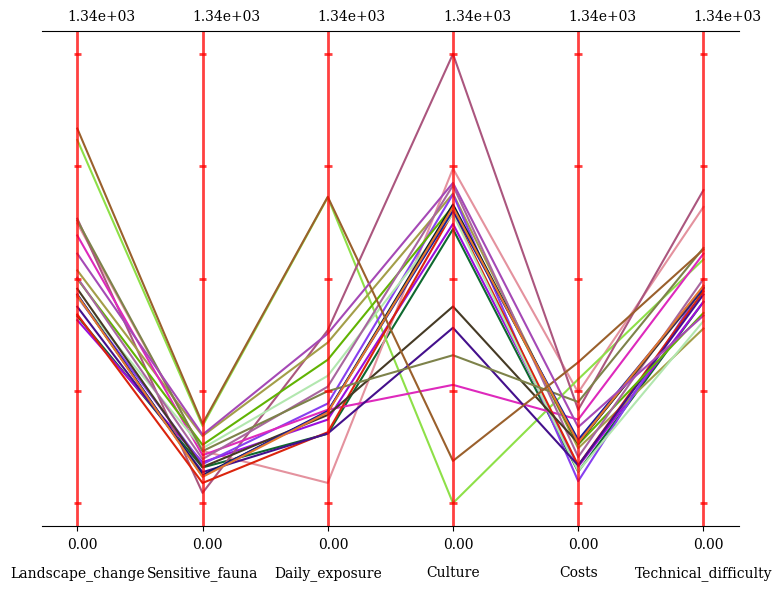

In [11]:
# Plot the extent of those MCDA solutions
plot = PCP(labels=objective_names, cmap="viridis", tight_layout=True)
M = np.random.rand(F_mcda.shape[0],3)
plot.reset()
plot.normalize_each_axis = False
for i, F_i in enumerate(F_mcda):
    plot.add(F_i, color=M[i]) 
plot.show()

In [12]:
# Perform some checks for values (should be only True and False) and dtype
# before mutation:
print("parents dtype:", parents.dtype, "\texisting values:", np.unique(parents))

# after mutation: 
print("children dtype:", children.dtype, "\texisting values:", np.unique(children))
print("initial population dtype:", initial_population.get("X").dtype, "\texisting values:", np.unique(initial_population.get("X")))
print("initial population shape: ", initial_population.shape)

# Study dominance within the first population
nds = NonDominatedSorting()
F_initial = initial_population.get("F")
G_initial = initial_population.get("G")
fronts = nds.do(F_initial)

# Front 0 = Pareto front
pareto_initial_pop = fronts[0]

print(f"Size initial population: {len(F_initial)}")
print(f"Non-dominated initial individuals: {len(pareto_initial_pop)}")
print(f"Fraction non-dominated: {len(pareto_initial_pop)/len(F_initial):.2f}")
print(f"Number of unfeasible individuals: {np.sum([np.any(G_initial > 0, axis=1)])}")

# To assess the initial spread of objective values
Fnorm = (F_mcda - Fmin) / (Fmax - Fmin + 1e-12)
print(f"Euclidian distance of initial objective values: {pdist(Fnorm, metric='euclidean').mean()}")

parents dtype: bool 	existing values: [False  True]
children dtype: bool 	existing values: [False  True]
initial population dtype: bool 	existing values: [False  True]
initial population shape:  (20,)
Size initial population: 20
Non-dominated initial individuals: 11
Fraction non-dominated: 0.55
Number of unfeasible individuals: 9
Euclidian distance of initial objective values: 0.7951270840528994


# Algorithm definition with history callback and minimization

In [13]:
algorithm = NSGA2(
    pop_size=population_size,
    n_offsprings=n_offsprings,
    sampling=initial_population_array,
    crossover=TwoPointCrossover(),
    mutation=MyMutation(stabilization_generation=stabilization_generation, n_swaps=number_swaps),
    repair=MyRepair(),
    eliminate_duplicates=True,
)

class UltraLightHistoryCallback(Callback):
    def __init__(self, every=5):
        super().__init__()
        self.every = every
        self.X = []
        self.F = []
        self.gen = []

    def notify(self, algorithm):
        if algorithm.n_gen % self.every == 0:
            self.X.append(algorithm.pop.get("X").copy())
            self.F.append(algorithm.pop.get("F").copy())
            self.gen.append(algorithm.n_gen)

MyCallback = UltraLightHistoryCallback(every=5)

In [14]:
res = minimize(problem,
               algorithm,
               termination,
               seed=1,
               n_jobs=1,  # Utilize one core
               save_history=False,
               callback=MyCallback,
               verbose=True)

# Legend:
# n_gen     = generation number
# n_eval    = how many times the _evaluate() function has been called since the beginning of the run
# n_nds     = number of non-dominated solutions
# cv_min    = constraint violation of best solution, should be 0
# cv_avg    = average violation, if high, means most solutions violate the constraints
# eps       = convergence metric
# indicator = indicates where the most significant change occured (f = front, ideal = best point, nadir = worst point)

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       20 |     11 |  0.000000E+00 |  5.698136E+02 |             - |             -
     2 |       40 |     11 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     3 |       60 |     12 |  0.000000E+00 |  0.000000E+00 |  0.1093249422 |         nadir
     4 |       80 |     13 |  0.000000E+00 |  0.000000E+00 |  0.0024838452 |             f
     5 |      100 |     14 |  0.000000E+00 |  0.000000E+00 |  0.0040506578 |             f
     6 |      120 |     17 |  0.000000E+00 |  0.000000E+00 |  0.0191575922 |         nadir
     7 |      140 |     19 |  0.000000E+00 |  0.000000E+00 |  0.0025189811 |         nadir
     8 |      160 |     20 |  0.000000E+00 |  0.000000E+00 |  0.0018779784 |             f
     9 |      180 |     20 |  0.000000E+00 |  0.000000E+00 |  0.0018779784 |             f
    10 |      200 |     20 |  0.000000E+00 |  0.000000E+00 |  0.0303926892 |         nadir

In [15]:
# Save results
with open(result_filename, "wb") as f:
        dill.dump(res, f)

# Results post-processing

In [16]:
# ### If needed to do the post-processing with the results previously generated
# with open(result_filename, 'rb') as f:
#     res = dill.load(f)

In [17]:
# Store relevant variables
X = res.X
F = res.F
G = res.G

callback_X = res.algorithm.callback.X
cb_X = np.stack(callback_X, axis=0)
callback_F = res.algorithm.callback.F
cb_F = np.stack(callback_F, axis=0)
cb_gen = res.algorithm.callback.gen

In [18]:
# Create a dataframe of the solutions with relevant information
objective_names = [
    "Landscape change", "Sensitive fauna",
    "Daily exposure", "Culture",
    "Costs", "Technical difficulty"
]

solution_df = pd.DataFrame(F, columns=objective_names)
number_solutions = solution_df.shape[0]
print("Final number of solutions: ", number_solutions)
print("Final population's dtype:", X.dtype, "\texisting values:", np.unique(X))

production = X @ my_input_data['AEP_GWh'].values
kept_cells = X.sum(axis=1)

min_production = 100_000

solution_df["Production"] = production
solution_df["Overshoot_production"] = production / min_production
solution_df["Cells_kept"] = kept_cells

display(solution_df)

Final number of solutions:  20
Final population's dtype: bool 	existing values: [False  True]


,Landscape change,Sensitive fauna,Daily exposure,Culture,Costs,Technical difficulty,Production,Overshoot_production,Cells_kept
0,1114.785377,226.385096,909.379471,180.0,419.233441,764.712327,100008.948744,1.000089,1711
1,1099.199466,233.327670,908.646844,74.0,392.979848,741.547470,100015.424975,1.000154,1673
2,1129.429216,224.770245,909.375735,192.0,408.975882,786.184394,104096.203858,1.040962,1744
3,615.462457,116.556757,297.299435,922.0,65.531327,648.589815,100073.614436,1.000736,1214
4,546.096878,121.693446,249.235553,834.0,108.790329,600.729198,100037.818540,1.000378,1140
5,1084.294612,230.519421,912.863097,0.0,369.736385,727.560998,100025.382398,1.000254,1647
6,849.115982,30.443234,515.946884,1341.0,278.430758,934.508097,100012.241069,1.000122,1706
7,835.321130,155.658052,60.235821,999.0,330.328238,884.126086,100052.857092,1.000529,1486
8,860.562811,35.697694,522.644011,1333.0,291.593572,936.498368,100049.147575,1.000491,1716
9,694.767183,200.496029,479.311247,924.0,163.926933,521.171206,100024.325203,1.000243,1297


In [19]:
# Calculate the hypervolume evolution, can take some time
hv_instance = HV(ref_point=ref_point)
hv_values = []

for F_i in cb_F:
    nds = NonDominatedSorting().do(F_i, only_non_dominated_front=True)
    F_nd = F_i[nds]
    hv_values.append(hv_instance.do(F_nd))

hv_values = np.array(hv_values)

In [20]:
# Calculate some diversity metrics. X diversity can take some time
n = cb_X.shape[0]

X_diversity = np.empty(n)
F_diversity = np.empty(n)
effective_dimension = np.empty(n, dtype=int)

for i in range(n):

    # Compute the genetic diversity of the spatial distribution X using the Jaccard metric
    Xi = cb_X[i].astype(bool).astype(int)
    X_diversity[i] = pdist(Xi, metric='jaccard').mean()

    # Compute the genetic diversity of the resulting objective values F using the Euclidean distance
    Fi = cb_F[i]
    Fnorm = (Fi - Fmin) / (Fmax - Fmin + 1e-12)
    F_diversity[i] = pdist(Fnorm, metric='euclidean').mean()

    # Compute the effective dimension of the Pareto front using Principal Component Analysis (PCA), counting how many variables are needed to explain 95% of the shape of the front
    Fnorm_2 = (Fi - Fi.min(axis=0)) / (Fi.max(axis=0) - Fi.min(axis=0) + 1e-12)
    pca = PCA().fit(Fnorm_2)
    cumul = np.cumsum(pca.explained_variance_ratio_)
    effective_dimension[i] = np.searchsorted(cumul, 0.95) + 1

diversity_metrics = np.column_stack((X_diversity, F_diversity, effective_dimension))

In [21]:
# Assess the relative dominance of final solutions to each other and with respect to MCDA solutions
nds = NonDominatedSorting()
fronts = nds.do(F)
pareto_final_pop = fronts[0]
print(f"Non-dominated final individuals: {len(pareto_final_pop)}")


def dominates(a, b):
    """
    Returns True if solution a dominates solution b (minimization).
    """
    return np.all(a <= b) and np.any(a < b)

def mcda_dominates_nsga(F_1, F_2):
    """
    Checks if ANY F_1 solution dominates ANY F_2 solution.
    """
    dominating_pairs = []
    for i, mc in enumerate(F_1):
        for j, ns in enumerate(F_2):
            if dominates(mc, ns):
                dominating_pairs.append((i, j))
    return dominating_pairs


pairs = mcda_dominates_nsga(F_mcda[:11], F)
print(f"MCDA → NSGA dominating pairs: {len(pairs)}")
if pairs:
    print("Example dominating pair (mcda_idx, nsga_idx):", pairs[0])
print()


pairs_nsga = mcda_dominates_nsga(F, F_mcda[:11])
print(f"NSGA → MCDA dominating pairs: {len(pairs_nsga)}")
if pairs_nsga:
    print("Example dominating pair (nsga_idx, mcda_idx):", pairs_nsga[0])
print()

Non-dominated final individuals: 20
MCDA → NSGA dominating pairs: 0

NSGA → MCDA dominating pairs: 0



# Results overview

In [22]:
mcda_color_scale_7_objectives = ['#2ca02c', '#1f77b4','#e377c2','#9467bd','#ff7f0e','#d62728','#8c564b']

objective_names_7 = [
    "Landscape change", "Sensitive fauna",
    "Daily exposure", "Culture",
    "Costs", "Technical difficulty",
    "Total impact"
]

# When the MCDA solutions were initially generated, the order of the indicators was different than currently, and there were additional indicators. This cell fixes this for the results analysis notebook.
# initial order = ["AEP_GWh_efficient", "Daily_exposure", "Culture", "Landscape_change", "Sensitive_fauna", "Technical_difficulty", "Costs", "Social_indicator", "Environmental_indicator", "Technical_indicator", "Global_indicator"]
rows_6 = [3, 4, 1, 2, 6, 5]         # just the 6 main optimization objectives
rows_7 = [3, 4, 1, 2, 6, 5, 10]     # including the total impacts

F_mcda_6_objectives = F_mcda[rows_6]
F_mcda_7_objectives = F_mcda[rows_7]

X_mcda_6_objectives = initial_parents[rows_6]
X_mcda_7_objectives = initial_parents[rows_7]

In [23]:
def plot_metrics(diversity_metrics, hv_values=hv_values, generations=cb_gen):
    plt.plot(generations, hv_values)
    plt.xlabel("Generation")
    plt.ylabel("Hypervolume")
    plt.title("Convergence")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    X_diversity, F_diversity, effective_dimension = diversity_metrics[:,0], diversity_metrics[:,1], diversity_metrics[:,2]

    plt.plot(generations, X_diversity)
    plt.xlabel("Generation")
    plt.ylabel("X-diversity")
    plt.title("Spatial diversity")
    plt.grid(True)
    plt.tight_layout()    
    plt.show()   

    plt.plot(generations, F_diversity)
    plt.xlabel("Generation")
    plt.ylabel("F-diversity")
    plt.title("Objective diversity")
    plt.grid(True)
    plt.tight_layout()
    plt.show() 

    plt.plot(generations, effective_dimension)
    plt.xlabel("Generation")
    plt.ylabel("Effective dimension")
    plt.title("Pareto front effective dimension")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



def scatter_matrix(F, F_mcda, solution_df, labels):
    n = F.shape[1]
    n_mcda = F_mcda.shape[0]
    fig, axes = plt.subplots(n-1, n-1, figsize=(2*n, 2*n))

    # One color per solution (row)
    #colors = plt.cm.viridis(np.linspace(0, 1, F.shape[0]))
    # alternatively: colors = np.random.rand(F.shape[0], 3)
    
    # Scalar per solution
    #score = solution_df["Total_impact_per_TWh"]   # shape (400,) works because F is in the same order as solution_df, otherwise use next line
    score = 1000 * F.sum(axis=1) / min_production     # for studying evolution of callback_F (approximate per TWh)
    # Color by sum of objectives
    norm = Normalize(vmin=18, vmax=52)      #score.min(), vmax=score.max())
    cmap = plt.cm.turbo
    colors = cmap(norm(score))


    for i in range(1, n):
        for j in range(n-1):
            ax = axes[i-1, j]

            #ax.set_xlim(0,16)
            #ax.set_ylim(0,16)
            if i == j:
                # Diagonal: histogram
                #ax.hist(F[:, i], bins=20, alpha=0.7)
                ax.set_axis_off()

            elif i > j:
                # Off-diagonal: scatter
                ax.scatter(F[:, j], F[:, i], c=colors, s=10, alpha=0.4)

                # Plot the MCDA solutions, there are 6 of those. Keep the labels only once
                #if i < n_mcda and j < n_mcda:
                if i == 1 and j == 0:
                    for idx in range(n_mcda):
                        ax.scatter(F_mcda[idx, j], F_mcda[idx, i], c=mcda_color_scale_7_objectives[idx], marker="*", s=100, label=objective_names_7[idx] + " MCDA")
                else:                        
                    for idx in range(n_mcda):
                        ax.scatter(F_mcda[idx, j], F_mcda[idx, i], c=mcda_color_scale_7_objectives[idx], marker="*", s=100)                              

            else:
                ax.set_axis_off()

            # Label only leftmost column and bottom row
            if j == 0:
                ax.set_ylabel(labels[i])
            else:
                ax.set_yticklabels([])

            if i == n - 1:
                ax.set_xlabel(labels[j])
            else:
                ax.set_xticklabels([])


    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    fig.suptitle("MOO solutions scattered according to objective values per TWh and color-scaled by total impact per TWh, \n with MCDA solutions scattered as stars with distinct colors")
    fig.legend(loc="center right")
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=axes,
        location="bottom",
        label="Total impact per TWh",
        fraction=0.025,   # thickness
        pad=0.05          # space from plots
    )
    plt.show()




def plot_ParallelPlot(F, F_mcda):
    plot = PCP(title=("Objective values before and after optimization", {'pad': 30}),
           legend=(True, {'loc': "upper left"}),
           labels=objective_names,
           tight_layout=True)
    plot.set_axis_style(color="grey", alpha=1)

    plot.normalize_each_axis = False

    plot.add(F_mcda[0], color="tab:orange", label="Before")
    plot.add(F[0], color="tab:blue", label="After")
    plot.add(F, color="tab:blue")
    plot.add(F_mcda, color="tab:orange")
    
    plot.show()
    plt.show()

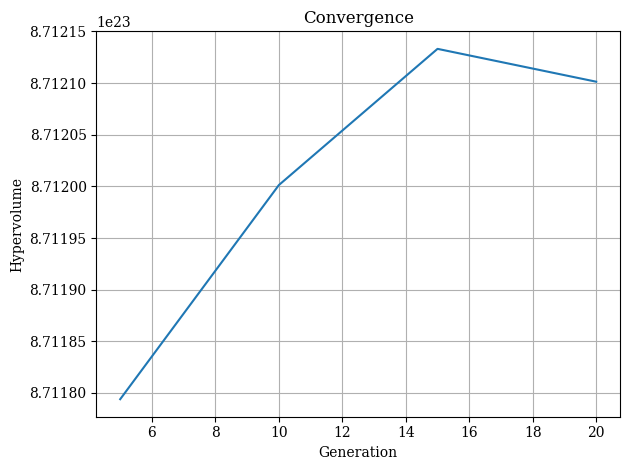

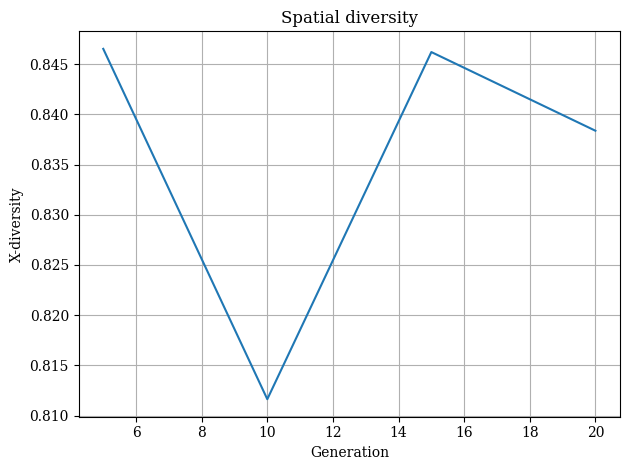

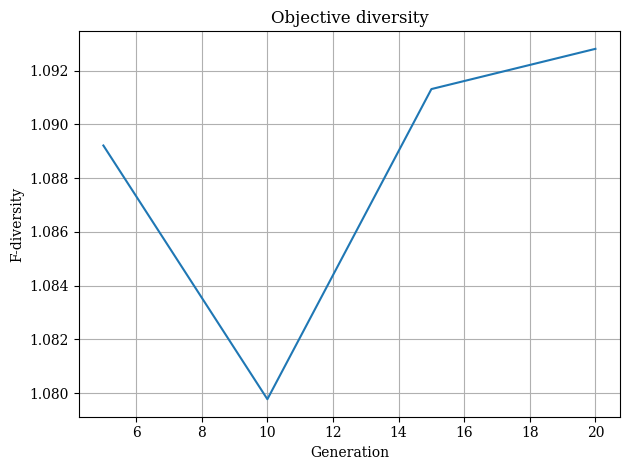

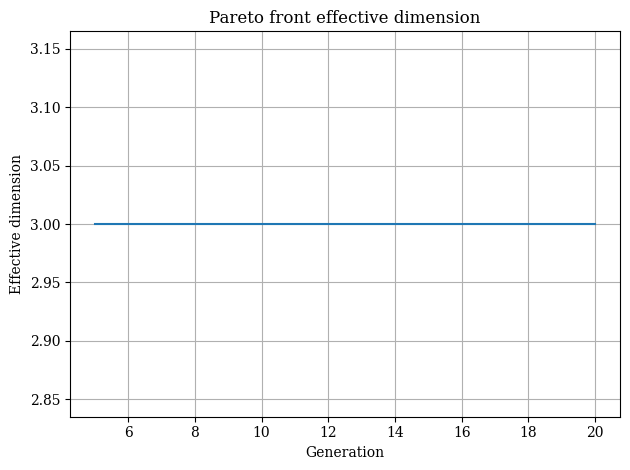

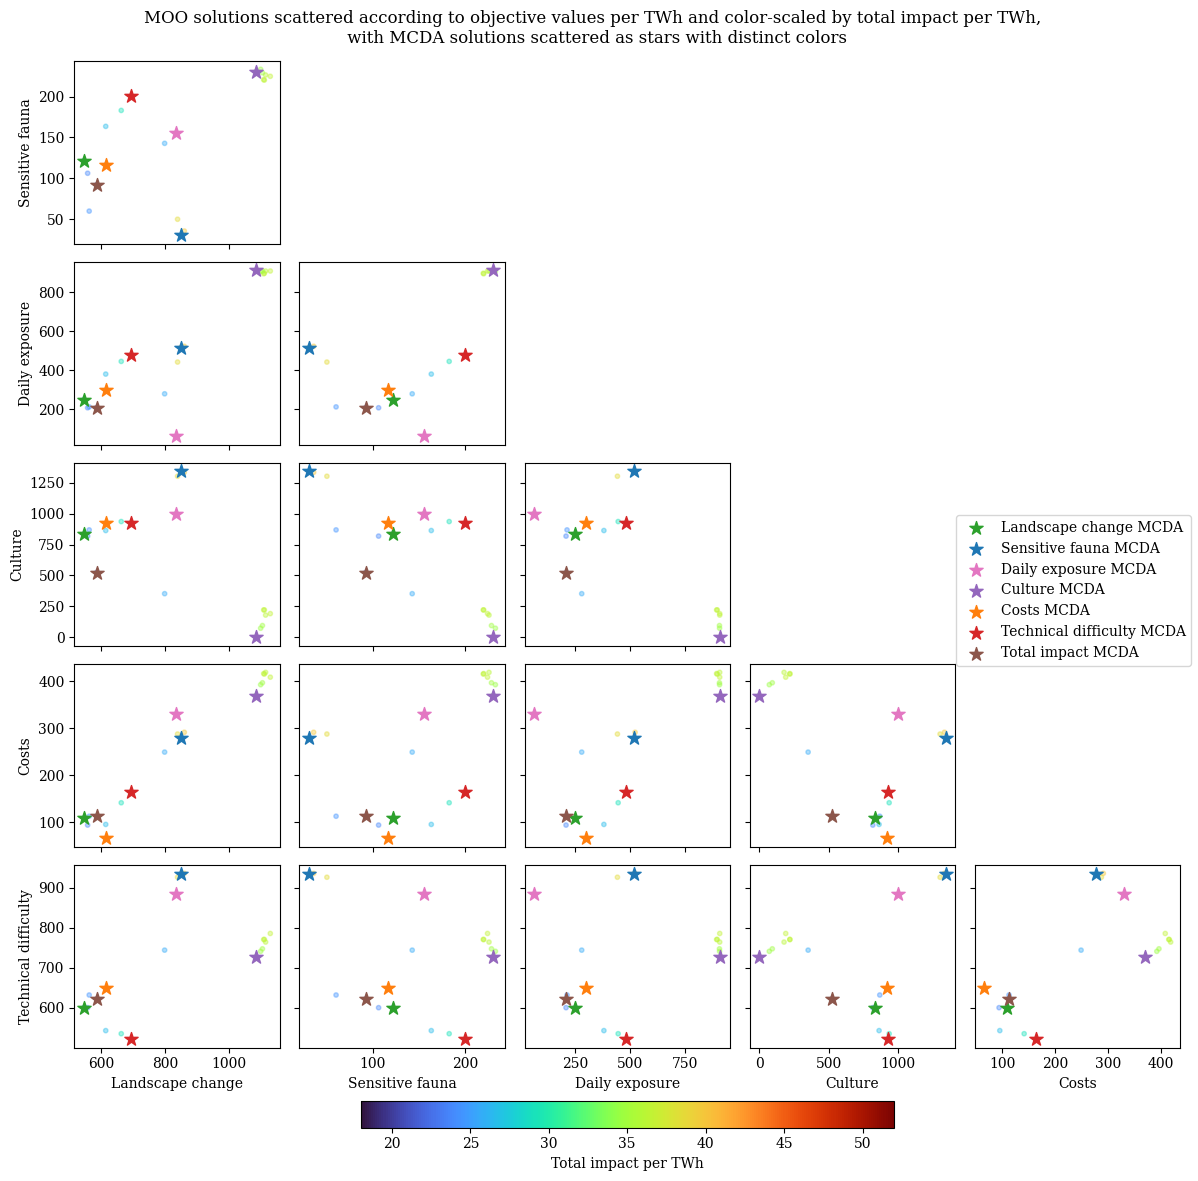

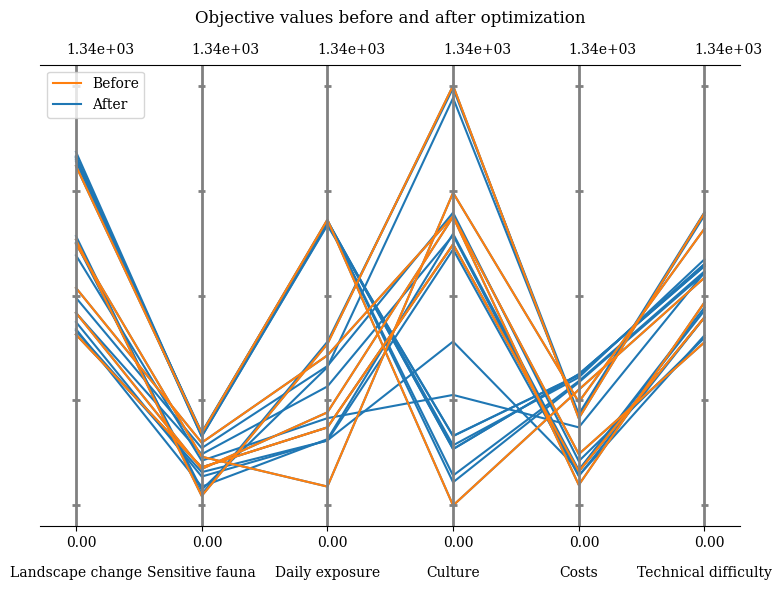

In [24]:
plot_metrics(diversity_metrics)
scatter_matrix(F, F_mcda_7_objectives, solution_df, objective_names)

plot_ParallelPlot(F, F_mcda_6_objectives)

In [25]:
def plot_X_robustness(X=X, my_input_data=my_input_data): 
    unit_counts = {}
    for i in range(len(my_input_data)):
        unit_counts[i] = 0

    # Iterate through the optimal solutions
    for solution in X:
        # Get indices of selected units (assuming binary solutions)
        selected_indices = np.where(solution == True)[0]
        # Increment counts for selected units
        for idx in selected_indices:
            unit_counts[idx] += 1

    # Print the counts
    #for unit_id, count in unit_counts.items():
    #    print(f"Planning Unit {unit_id}: {count} occurrences")
    count_series = pd.Series({k: v for k, v in unit_counts.items()}, name="Optimizer_selection_count")
    my_input_data_temp = my_input_data.copy().reset_index(drop=True)  # Drop the old index
    if "Optimizer_selection_count" in my_input_data_temp.columns:
        my_input_data_temp = my_input_data_temp.drop(columns="Optimizer_selection_count")
    my_input_data_temp = my_input_data_temp.join(count_series)
    my_input_data_temp["Optimizer_selection_frequency"] = my_input_data_temp["Optimizer_selection_count"] / len(X)
    # Threshold for continuous color scale
    threshold = 0
    #threshold = 0.01  # adjust as needed

    # Copy to avoid SettingWithCopyWarning
    gdf = my_input_data_temp.copy()

    # Values below threshold should not influence the continuous colormap
    gdf["color_value"] = gdf["Optimizer_selection_frequency"].where(
        gdf["Optimizer_selection_frequency"] > threshold,
        None  # or np.nan
    )

    # Discrete bins (edit as needed)
    bins = [threshold, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    labels = ["0.0–0.1", "0.1–0.2", "0.2–0.3", "0.3–0.4", "0.4–0.5", "0.5–0.6", "0.6–0.7", "0.7–0.8", "0.8–0.9", "0.9–1.0"]

    # Right boundary is included in the cut
    gdf["bin"] = pd.cut(
        gdf["Optimizer_selection_frequency"],
        bins=bins,
        labels=labels,
        include_lowest=False
    )

    # Discrete colormap
    cmap = plt.get_cmap("viridis", len(labels))

    fig, ax = plt.subplots(figsize=(12, 12))

    gdf.plot(
        column="bin",
        ax=ax,
        cmap=cmap,
        linewidth=0.2,
        edgecolor=None,
        missing_kwds={
            "color": "white", 
            "edgecolor": "lightgrey", 
            "label": f"< {threshold}"}
    )

    # Discrete colorbar
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=mcolors.BoundaryNorm(range(len(labels)+1), cmap.N)
    )
    cbar = fig.colorbar(sm, ax=ax, ticks=np.arange(len(labels)) + 0.5)
    cbar.ax.set_yticklabels(labels)
    cbar.set_label("Frequency of selection")

    ax.set_title("Cell robustness")
    plt.show()

    return gdf

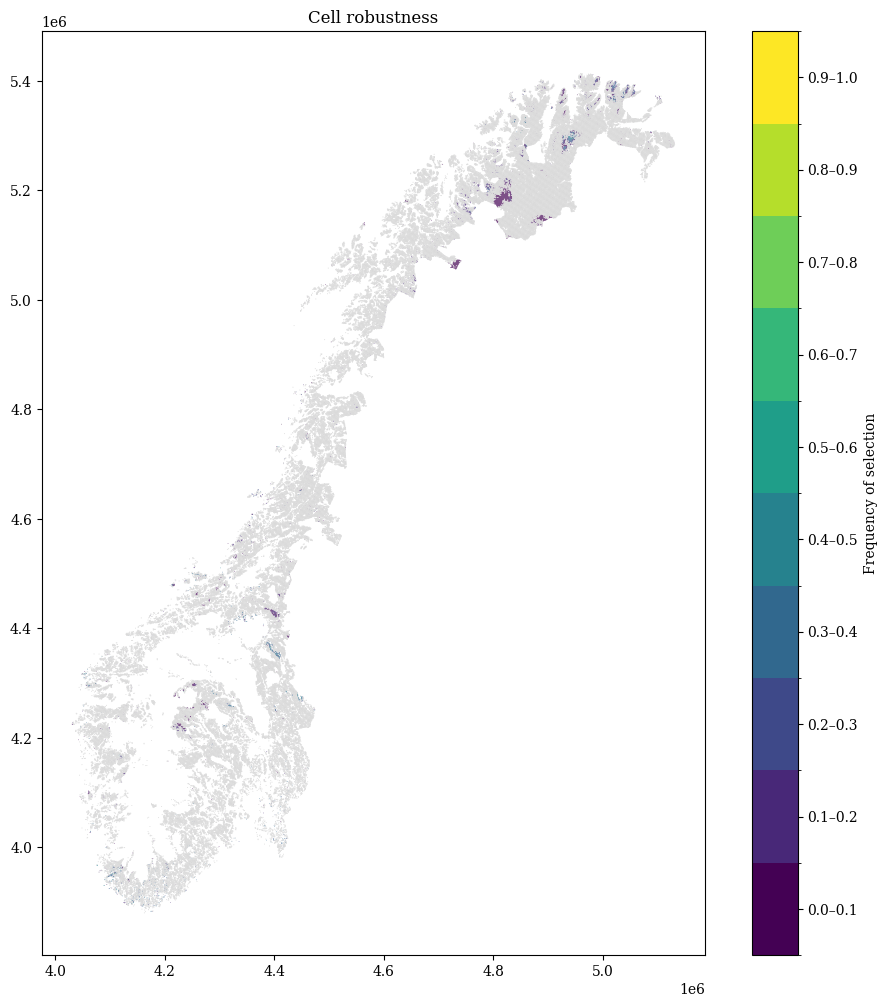

In [26]:
X_robustness = plot_X_robustness(X, my_input_data)

# Save the desired side-results

In [27]:
# Save X of MCDA parents if necessary
np.savetxt(X_mcda_filename, initial_parents, fmt="%d", delimiter=",")

# Save objective values of the MCDA parents for later analysis
np.save(F_mcda_filename, F_mcda_parents)

# Callback results
np.save(cb_X_filename, cb_X)
np.save(cb_F_filename, cb_F)
np.save(cb_gen_filename, cb_gen)

# Diagnostics results: hypervolume and diversity evolution
np.save(hv_filename, hv_values)
np.save(diversity_metrics_filename, diversity_metrics)